# Inférence à partir de grands fichiers GeoTiff en utilisant le package GeoInference

Suite au tutoriel `GDL_Training`, nous souhaitons maintenant utiliser le modèle entraîné et effectuer une inférence à partir de fichiers raster geotif. Les rasters doivent avoir le même nombre/ordre de bandes et des caractéristiques spectrales/géospatiales similaires à l'imagerie utilisée pour l'entraînement. Les rasters peuvent être très grands avec des milliers de pixels dans chaque dimension. Par conséquent, pour l'inférence, un mécanisme de tuilage/patchage est nécessaire car le modèle attend de petits patches (dans notre tutoriel, nous avons entraîné le modèle avec des patches de taille 512x512 pixels). NRCan a développé une bibliothèque légère (https://github.com/NRCan/geo-inference) qui gérera cette tâche de manière transparente et créera également des sorties dans divers formats utiles et compatibles avec les SIG.

## Préparation de l'environnement Python

Pour commencer, nous devons installer le package geo-inference dans notre environnement. Nous supposerons que nous avons déjà créé un environnement "tutorial" en utilisant les fichiers de requirements disponibles à la racine de ce dépôt.
- [Si vous avez un GPU disponible sur votre appareil](https://github.com/geoaiclassroom/geoai_learning/blob/main/requirements_gpu.txt)
- [Si vous n'avez que le CPU disponible sur votre appareil](https://github.com/geoaiclassroom/geoai_learning/blob/main/requirements_cpu.txt)

Ensuite, nous devons ajouter geo-inference à cet environnement.

Pour ce faire, activez votre environnement "tutorial" (*conda activate tutorial*) et entrez (*cd*) dans le répertoire Tutorial7 où le fichier [constraints.txt](constraints.txt) est placé.

Ensuite, installez le package :

    pip install geo-inference -c constraints.txt

Pour vérifier si l'installation a réussi :

    conda list geo-inference

Cela devrait montrer que la version actuelle (en date de juin 2026, 3.2.4) de geo-inference est disponible. Nous sommes maintenant prêts à suivre ce tutoriel !

In [ ]:
# Exécutez cette cellule pour corriger l'erreur "RuntimeError: This event loop is already running" lors de l'exécution de l'inférence dans le notebook. Il s'agit d'un problème connu avec les notebooks Jupyter et le code asynchrone, et nest_asyncio est une solution de contournement courante.
# De plus, en raison de certains conflits avec nos versions rasterio/gdal, l'ordre d'importation de torch par rapport à gdal est important - nous devons donc importer torch en premier pour éviter les conflits de bibliothèques dynamiques.
import torch
import nest_asyncio
nest_asyncio.apply()

In [ ]:
# Exécutez cette cellule si vous exécutez ce tutoriel sur une machine Windows.

# Solution de contournement pour le verrouillage de fichiers Windows lors d'écritures chunked rioxarray+dask.
# geo_inference passe un verrou, ce qui fait que les écritures rioxarray rouvrent le même TIFF de sortie en r+ par chunk ;
# cette opération peut échouer sur Windows avec une erreur exprimant "file used by other process".

import rioxarray.raster_array as rxr_raster_array

_original_to_raster = rxr_raster_array.RasterArray.to_raster

def _to_raster_windows_safe(self, *args, **kwargs):
    kwargs["lock"] = False
    kwargs["windowed"] = False
    return _original_to_raster(self, *args, **kwargs)

rxr_raster_array.RasterArray.to_raster = _to_raster_windows_safe
print("Applied Windows-safe rioxarray to_raster patch (lock=False, windowed=False).")

Applied Windows-safe rioxarray to_raster patch (lock=False, windowed=False).


In [3]:
import zipfile
from pathlib import Path
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import rasterio
from geo_inference.geo_inference import GeoInference


## Scripting du modèle

Nous allons expérimenter avec geo-inference en utilisant le modèle entraîné dans le dernier tutoriel (le checkpoint se trouve dans votre dossier d'exécution MLFlow sous le sous-dossier "checkpoints").

Avant que ce modèle ne devienne lisible par geo-inference, nous devons le scripter.

Un modèle scripté (modèle TorchScript) est essentiellement le modèle PyTorch entraîné converti en une version autonome et portable qui ne dépend plus de notre code Python original (la définition de la classe du modèle). Au lieu d'avoir besoin de notre classe de modèle, de modules personnalisés et d'un environnement complet pour fonctionner, le modèle scripté regroupe tout dans un seul fichier .pt qui peut être chargé et exécuté indépendamment (même en dehors de Python, par ex., en C++ ou dans des systèmes de production).

Nous pouvons utiliser le script [export_model_to_torchscript.py](export_model_to_torchscript.py) qui prend un checkpoint sauvegardé (.ckpt), charge le modèle, et le convertit dans ce format TorchScript afin qu'il devienne plus facile à déployer, partager et exécuter de manière cohérente—souvent avec un prétraitement intégré comme la normalisation—sans se soucier de reconstruire la configuration d'entraînement. C'est exactement ce que le package geo-inference attend !

```
    python export_model_to_torchscript.py 
    --checkpoint "path/to/your_model.ckpt"
    --output "path/to/store/scripted.pt"
    --device cuda
    --use-tracing
    --mean 0.5 0.5 0.5
    --std 0.2 0.2 0.2
```

Notez que vous devez changer le device en cpu si vous n'avez pas de GPU disponible, et les valeurs mean/std doivent être les mêmes que celles utilisées pendant l'entraînement.

## Échantillon de données pour l'inférence

Les données pour ce tutoriel sont une petite portion de l'imagerie aérienne de la ville de Waterloo.

Les informations sur ces données, y compris les détails de la licence, peuvent être trouvées ici : https://data.waterloo.ca/documents/ccaa282007ef43e4bfae01169762f15a/about

Une petite portion de l'imagerie est [recadrée sous forme de fichier raster tif](Data/waterloo_crop_2020.zip) pour les besoins de ce tutoriel léger.

In [ ]:
zip_path = Path("./Data/waterloo_crop_2020.zip")
extract_dir = zip_path.with_suffix("")  # supprime .zip

# Décompresser uniquement si ce n'est pas déjà fait
if not extract_dir.exists():
    print(f"Extracting to {extract_dir}...")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_dir)
else:
    print(f"{extract_dir} already extracted.")

Data\waterloo_crop_2020 already extracted.


## Exécution de l'inférence
Nous pourrions soit exécuter l'inférence sur notre fichier geotif en utilisant des arguments de ligne de commande, soit en définissant tout dans un fichier de configuration. Le dépôt geo-inference vous fournit des détails sur la façon dont un fichier de configuration pourrait être défini. Pour plus de clarté, dans ce tutoriel, nous définirons tout comme arguments.

In [ ]:
# Répertoire de sortie unique par exécution pour éviter les collisions de chemins
base_work_dir = Path(r"./Data/waterloo_crop_2020")
run_work_dir = base_work_dir / f"run_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
run_work_dir.mkdir(parents=True, exist_ok=True)

# Initialiser l'objet GeoInference
geo_inf = GeoInference(
    model=r"./logs/mlrun/scripted.pt",
    work_dir=str(run_work_dir),
    mask_to_vec=True,
    mask_to_yolo=False,
    mask_to_coco=False, 
    device="gpu",
    multi_gpu=False,
    gpu_id=0, 
    num_classes=2,
    prediction_threshold=0.5,
    transformers=True,
    transformer_flip=False,
    transformer_rotate=True,
)


In [ ]:
# Effectuer l'extraction de caractéristiques sur une image TIFF
image_path = r"./Data/waterloo_crop_2020/waterloo_crop_2020.tif"
bands_requested = [1, 2, 3] # bandes RGB
workers = 1
patch_size = 512
# bbox = "0, 0, 1000, 1000"
geo_inf(
    inference_input = image_path,  
    bands_requested = bands_requested, 
    patch_size = patch_size, 
    workers = workers, 
    bbox=None
)

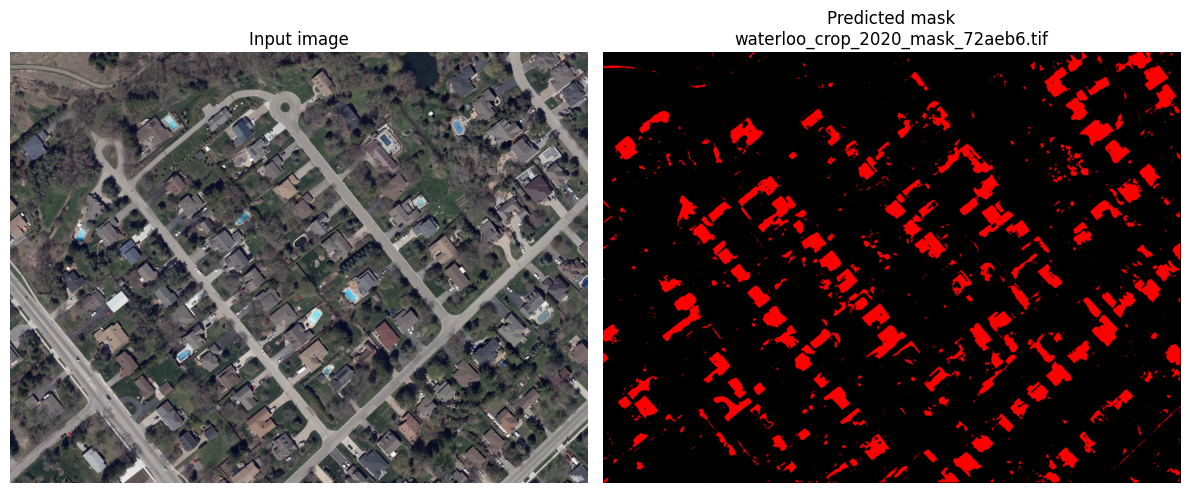

In [ ]:
# Tracer l'image d'entrée et le masque prédit côte à côte pour inspection visuelle
def plot_image_and_mask(image_path, run_work_dir):
    """Plots the input image and the latest predicted mask from the given run_work_dir side by side."""

    # Lire l'image d'entrée (3 premières bandes) et convertir en HWC pour le tracé
    with rasterio.open(image_path) as src:
        img = src.read([1, 2, 3]).astype(np.float32)  # C, H, W
    img = np.transpose(img, (1, 2, 0))  # H, W, C

    # Étirer l'image à [0, 1] pour l'affichage
    img_min = np.nanmin(img)
    img_max = np.nanmax(img)
    if img_max > img_min:
        img_disp = (img - img_min) / (img_max - img_min)
    else:
        img_disp = np.zeros_like(img)

    # Trouver le dernier masque de sortie dans le dossier d'exécution actuel
    mask_candidates = sorted(Path(run_work_dir).glob("*_mask_*.tif"), key=lambda p: p.stat().st_mtime)
    if not mask_candidates:
        raise FileNotFoundError(f"No mask found in {run_work_dir}. Run inference first.")
    mask_path = mask_candidates[-1]

    with rasterio.open(mask_path) as src:
        mask = src.read(1)

    # Diagnostics : inspecter les valeurs réelles dans le masque
    # vals, counts = np.unique(mask, return_counts=True)
    # print(f"Mask path: {mask_path}")
    # print("Unique values and counts:")
    # for v, c in zip(vals, counts):
    #     print(f"  {int(v)}: {int(c)}")

    # geo_inference écrit nodata comme 255 ; ignorer nodata pour l'affichage
    mask_plot = mask.astype(np.float32)
    mask_plot[mask_plot == 255] = np.nan

    # Utiliser une carte de couleurs discrète pour que la classe 0 et la classe 1 soient visuellement différentes
    # classe 0 -> noir, classe 1 -> rouge
    discrete_cmap = ListedColormap(["black", "red"])

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(img_disp)
    axes[0].set_title("Input image")
    axes[0].axis("off")

    im = axes[1].imshow(mask_plot, cmap=discrete_cmap, vmin=0, vmax=1)
    axes[1].set_title(f"Predicted mask\n{mask_path.name}")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

plot_image_and_mask(image_path, run_work_dir)